# 06 Optimization Techniques

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Compare SGD and Adam optimizers on the same task (MNIST digits)
- See how the choice of optimizer affects loss curves and convergence
- Understand why we often use Adam instead of plain SGD

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 3, lesson 01 "Optimizers: SGD, Adam, and More" — the same comparison on a small mathematical problem; here it decides whether a network trains at all.

**Used later in:** Course 10 (AIAT 124) — Unit 1, lesson 08 "Training Techniques: Gradient Penalties and Spectral Normalization" — where optimizer choice keeps a GAN from collapsing.

---

## 🌍 Real life

**📌 Real case — the benchmark that refused to crown a winner.** Schmidt, Schneider and Hennig (ICML 2021, arXiv 2007.01547) took **15 popular deep-learning optimizers**, ran them across eight problems in more than **50,000 individual training runs**, and reported that they "cannot discern an optimization method clearly dominating across all tested tasks" — Adam remained a strong contender and newer methods failed to consistently beat it. Their other finding is the practical one: evaluating a handful of optimizers at their default settings works about as well as carefully tuning a single fixed optimizer. The controlled A/B you are about to run is one cell of that study.

**⚡ Why this matters — what goes wrong without it.** With plain SGD, one learning rate you picked by hand has to be right for every weight in the network at every stage of training. Too small and you get our SGD curve: after five full epochs the loss has crawled from **2.2758 to 1.8973** — the model has barely started. Too large and it diverges. Adam sidesteps the choice by giving every parameter its own effective step size. Same model, same data, **identical starting weights**: **0.3352**.

**Where is this used?** Every time you train a neural network you choose an **optimizer** that uses the gradients from backprop to update the weights (e.g. `optim.Adam(...)` in PyTorch or `optimizer='adam'` in Keras).

**In this notebook we use** **optimizers** (SGD and Adam) to **update the weights** so the network learns. We use **Adam** instead of plain **SGD** in many projects **because** Adam adapts the learning rate per parameter and usually **converges faster** and more reliably.

**📌 Covers slide(s):** Part of Unit 1 sequence (training flow). *Do after 05_backpropagation_detailed; then move to Unit 2.*

---

**Before starting:** Run the imports cell below. Requires PyTorch.


## Theory (short)

- **Optimizer** = algorithm that uses gradients to update weights: `new_weight = old_weight - learning_rate * gradient` (or a variant).
- **SGD (Stochastic Gradient Descent):** uses the gradient directly; simple but can be slow and sensitive to learning rate.
- **Adam:** adapts a learning rate per parameter (momentum + scaling); usually converges faster and is less sensitive to the initial learning rate.
- **Data flow:** forward pass → loss → backprop (gradients) → **optimizer** updates weights → repeat.

### Key math (required)

- **SGD:** \(w_{t+1} = w_t - \eta\, g_t\) where \(g_t = \nabla_w L\) (gradient of loss w.r.t. \(w\)) and \(\eta\) is the learning rate.
- **Adam:** maintains running estimates of the first moment \(m\) and second moment \(v\) of gradients; update: \(m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t\), \(v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2\), then bias-correct and apply \(w_{t+1} = w_t - \eta\,\hat{m}_t/(\sqrt{\hat{v}_t}+\epsilon)\). Typical \(\beta_1=0.9\), \(\beta_2=0.999\). See slides or Kingma & Ba (2014) for full form.

**The steps below put this theory into code.**

💡 **If this is unclear:** Focus on the **plot at the end**: one curve is SGD, one is Adam; Adam usually reaches lower loss in the same number of epochs. The main idea: optimizers use gradients to update weights; Adam adapts the step size per parameter. If stuck, tell your instructor: "I didn't get the SGD vs Adam part in notebook 06."


## 📥 Inputs & 📤 Outputs

**Inputs:** MNIST (we use a subset of 5k training samples), PyTorch, NumPy, Matplotlib. We build two identical small models in the notebook and train one with SGD and one with Adam.

**Dataset:** Real — MNIST (subset for SGD vs Adam comparison).

**Outputs:** Printed training loss per epoch for SGD, then for Adam; then one plot with two curves (SGD train loss vs Adam train loss). Adam typically reaches lower loss in the same number of epochs.


In [1]:
# Step 1: Imports
# NumPy/Matplotlib for math and plots; torchvision supplies MNIST; DataLoader batches it.
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
print(f'PyTorch {torch.__version__}')
print('✅ Imports OK.')

PyTorch 2.13.0
✅ Imports OK.


In [2]:
# Step 2: Load MNIST (small subset so it runs fast)
transform = transforms.ToTensor()
train_data = datasets.MNIST('/tmp/mnist_data', train=True, download=True, transform=transform)
# Use first 5 000 samples for speed
subset = torch.utils.data.Subset(train_data, range(5000))
loader = DataLoader(subset, batch_size=128, shuffle=True)
print('Training on', len(subset), 'samples')

Training on 5000 samples


In [3]:
# Step 3: Factory function — same architecture used for both optimizers
def make_model():
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 64), nn.ReLU(),
        nn.Linear(64, 10),
    )

model_sgd  = make_model()
model_adam = make_model()
# Copy weights so both models start identically
model_adam.load_state_dict(model_sgd.state_dict())
print('Both models initialised with identical weights')

Both models initialised with identical weights


In [4]:
# Step 4: Train with SGD
# SGD has a fixed learning rate; it takes longer to converge than Adam on many tasks.
criterion  = nn.CrossEntropyLoss()
opt_sgd    = optim.SGD(model_sgd.parameters(), lr=0.01)
losses_sgd = []
for epoch in range(5):
    model_sgd.train()
    epoch_loss = 0.0
    for xb, yb in loader:
        opt_sgd.zero_grad()
        loss = criterion(model_sgd(xb), yb)
        loss.backward()
        opt_sgd.step()
        epoch_loss += loss.item()
    losses_sgd.append(epoch_loss / len(loader))
    print(f'SGD  epoch {epoch+1}: loss={losses_sgd[-1]:.4f}')

SGD  epoch 1: loss=2.2758
SGD  epoch 2: loss=2.2049


SGD  epoch 3: loss=2.1138
SGD  epoch 4: loss=2.0150


SGD  epoch 5: loss=1.8973


In [5]:
# Step 5: Train with Adam (same architecture, same data, same starting weights)
# Adam adapts the learning rate per parameter — usually converges faster.
opt_adam    = optim.Adam(model_adam.parameters(), lr=1e-3)
losses_adam = []
for epoch in range(5):
    model_adam.train()
    epoch_loss = 0.0
    for xb, yb in loader:
        opt_adam.zero_grad()
        loss = criterion(model_adam(xb), yb)
        loss.backward()
        opt_adam.step()
        epoch_loss += loss.item()
    losses_adam.append(epoch_loss / len(loader))
    print(f'Adam epoch {epoch+1}: loss={losses_adam[-1]:.4f}')

Adam epoch 1: loss=1.5848
Adam epoch 2: loss=0.6876


Adam epoch 3: loss=0.4544


Adam epoch 4: loss=0.3934
Adam epoch 5: loss=0.3352


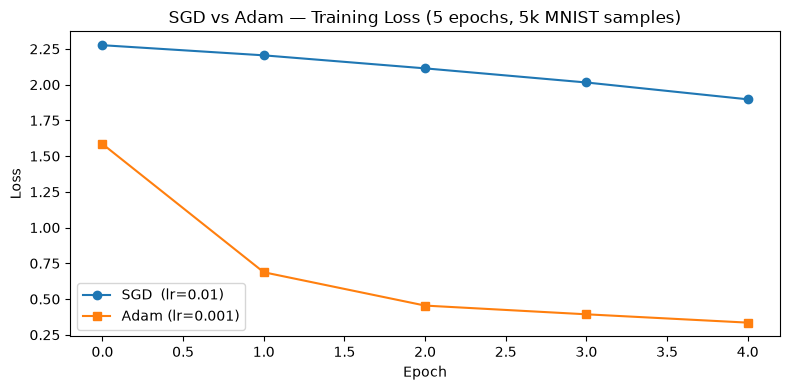

Adam final loss: 0.3352
SGD  final loss: 1.8973


In [6]:
# Step 6: Plot loss comparison — SGD vs Adam
# WHY: putting both optimizers' loss on one chart makes the speed difference obvious at a glance.
plt.figure(figsize=(8, 4))
plt.plot(losses_sgd,  label='SGD  (lr=0.01)', marker='o')
plt.plot(losses_adam, label='Adam (lr=0.001)', marker='s')
plt.title('SGD vs Adam — Training Loss (5 epochs, 5k MNIST samples)')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.tight_layout(); plt.show()
print('Adam final loss:', round(losses_adam[-1], 4))
print('SGD  final loss:', round(losses_sgd[-1],  4))

## 💬 Discuss

1. Both models started from **identical weights** and saw identical data, so the entire gap (SGD **1.8973** vs Adam **0.3352**) comes from the update rule. Now the harder question: is it a *fair* fight, given SGD ran at lr=0.01 and Adam at lr=0.001? Write down the experiment that would make it fair.
2. The SGD curve is still falling at epoch 5. Would 50 epochs of SGD beat 5 epochs of Adam? Which resource does that trade — your time or the machine's — and which is scarcer in your situation?
3. A colleague says "we switched to Adam and accuracy went up 4 points". List the three questions you ask before you believe it, in the order you would ask them.


## 🌍 Real-World Worked Example — Comparing Optimizers on Image Classification

**Industry context — quoted from the papers, not from memory.** The GPT-3 paper states "we use Adam with β1 = 0.9, β2 = 0.95" (Brown et al., 2020, [arXiv:2005.14165](https://arxiv.org/abs/2005.14165)). The T5 paper states "For optimization, we use AdaFactor" (Raffel et al., JMLR 2020, [arXiv:1910.10683](https://arxiv.org/abs/1910.10683)). Two of the most-copied training recipes in the field, two different optimizers — which is exactly why the comparison below is worth running yourself.

We compare SGD, RMSprop, and Adam on the **Digits** dataset to see the difference.

SGD (lr=0.01)        → final acc: 77.5%
RMSprop              → final acc: 97.8%
Adam                 → final acc: 97.5%


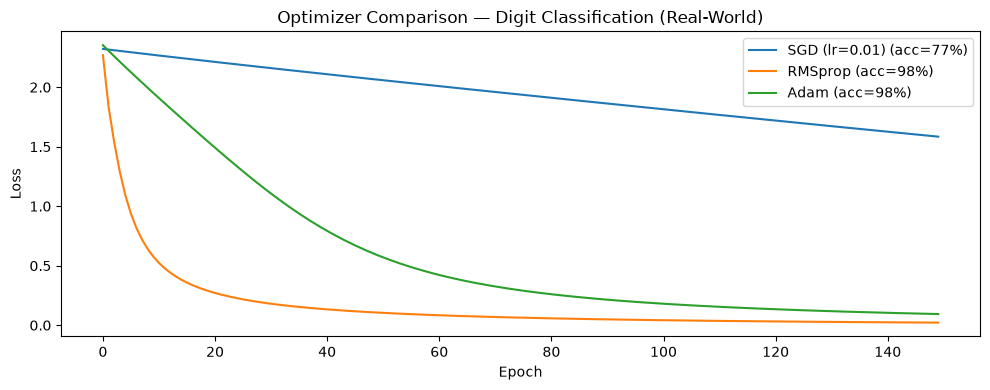

In [7]:
# WHAT: train the same small network three times, changing only the optimizer (SGD, RMSprop, Adam).
# WHY: with data, model and epochs held fixed, any difference in the loss curves comes from the update rule alone.
import torch, torch.nn as nn
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np, matplotlib.pyplot as plt

# Load the 8x8 digits dataset and standardize features so all optimizers start from comparable conditions.
digits = load_digits()
X = StandardScaler().fit_transform(digits.data.astype(np.float32))
y = digits.target
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
Xtr = torch.tensor(X_tr); Ytr = torch.tensor(y_tr, dtype=torch.long)
Xte = torch.tensor(X_te); Yte = torch.tensor(y_te, dtype=torch.long)

# A fresh model per optimizer - reusing weights would contaminate the comparison.
def make_model():
    return nn.Sequential(nn.Linear(64,128), nn.ReLU(), nn.Linear(128,10))

# The three contenders: plain SGD, RMSprop (adaptive step per weight), Adam (adaptive step + momentum).
optimizers = {
    'SGD (lr=0.01)':   lambda m: torch.optim.SGD(m.parameters(), lr=0.01),
    'RMSprop':         lambda m: torch.optim.RMSprop(m.parameters(), lr=1e-3),
    'Adam':            lambda m: torch.optim.Adam(m.parameters(), lr=1e-3),
}
results = {}
# Train 150 full-batch steps per optimizer and record the loss after each one.
for name, opt_fn in optimizers.items():
    model = make_model()
    opt   = opt_fn(model)
    loss_fn = nn.CrossEntropyLoss()
    curve = []
    for _ in range(150):
        model.train()
        loss = loss_fn(model(Xtr), Ytr)
        opt.zero_grad(); loss.backward(); opt.step()
        curve.append(loss.item())
    # Measure test accuracy with gradients off - training is done, we only evaluate.
    model.eval()
    with torch.no_grad():
        acc = (model(Xte).argmax(1)==Yte).float().mean().item()
    results[name] = (curve, acc)
    print(f"{name:20s} → final acc: {acc*100:.1f}%")

# One curve per optimizer: the faster-falling loss is the faster learner on this task.
plt.figure(figsize=(10,4))
for name,(curve,acc) in results.items():
    plt.plot(curve, label=f"{name} (acc={acc*100:.0f}%)")
plt.title("Optimizer Comparison — Digit Classification (Real-World)"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.tight_layout(); plt.show()

## ⚠️ Where this breaks

- **This experiment cannot tell you which optimizer generalises better.** We plotted *training* loss only. A lower training loss can mean better fitting or faster memorising, and nothing above distinguishes them. Add a validation curve before you draw a conclusion about quality.
- **The comparison is not perfectly fair, and it should say so.** SGD ran at `lr=0.01` and Adam at `lr=1e-3`. The starting weights were identical — genuinely good practice — but the step sizes were not tuned. A learning-rate sweep for SGD would close much of a gap this size.
- **Adam is not free.** It stores two extra numbers (the first and second moment) for every parameter, roughly tripling optimizer memory relative to plain SGD. On a large model that is exactly what decides whether training fits on your GPU at all.
- **Adam's edge shrinks or reverses with tuning and schedules.** Schmidt et al. found no dominant optimizer across 50,000+ runs. If a colleague reports "we switched to Adam and accuracy rose 4 points", the useful reply is a question about learning rates, not congratulations.
- **The assumption that must hold:** gradients carry usable signal. Where gradients are very sparse or very noisy, adaptive methods can amplify the noise instead of the signal.
- **Cheaper alternative:** for convex problems and small models, plain SGD with a decaying learning rate, or even a closed-form solver, is faster, simpler and fully predictable.


---

## 🧩 Mini-exercise

**Try it (choose one):** Train a third model with **RMSprop** (same architecture, 5 epochs) and add its loss curve to the plot. Compare SGD, Adam, and RMSprop. Or change the learning rate for SGD (e.g. 0.1 or 0.01) and see how the curve changes.

---

## ✅ Summary

**What you did:**
- Loaded MNIST subset and built two identical small models.
- Trained one with **SGD** and one with **Adam** for 5 epochs each.
- Plotted loss curves to compare; Adam often converges faster.

**In real life you'd also:** try different learning rates, use more epochs, and possibly try other optimizers (RMSprop, AdamW).

**The main idea:** The optimizer uses gradients from backprop to update weights; Adam adapts the step size per parameter and is often a good default.

**Next:** Unit 2 CNNs: e.g. `unit2-cnns/examples/01_cnn_architecture.ipynb`. Optionally, `07_image_processing_feature_extraction` (Unit 1) covers image basics before CNNs.


## 📚 References

1. Kingma, D. P. & Ba, J. (2015). *Adam: A Method for Stochastic Optimization*. ICLR. https://arxiv.org/abs/1412.6980
2. Ruder, S. (2016). *An overview of gradient descent optimization algorithms*. arXiv. https://arxiv.org/abs/1609.04747
3. Loshchilov, I. & Hutter, F. (2019). *Decoupled Weight Decay Regularization* (AdamW). ICLR. https://arxiv.org/abs/1711.05101
4. Schmidt, R. M., Schneider, F. & Hennig, P. (2021). *Descending through a Crowded Valley - Benchmarking Deep Learning Optimizers*. ICML. https://arxiv.org/abs/2007.01547

**Recent work (2024–2026)**

5. Liu, J. et al. (2025). *Muon is Scalable for LLM Training*. arXiv. https://arxiv.org/abs/2502.16982 — a 2025 optimizer that treats a layer's gradient as a matrix rather than a bag of scalars; the clearest recent challenge to the Adam/AdamW default this notebook compares.
6. Zhao, J. et al. (2024). *GaLore: Memory-Efficient LLM Training by Gradient Low-Rank Projection*. ICML 2024. https://arxiv.org/abs/2403.03507 — the memory side of the same question — the optimizer state, not the gradient computation, is what fills the GPU.
